# A/B-тест рекомендательного алгоритма

Цель проекта — спланировать A/B-тест нового алгоритма рекомендаций, проверить корректность распределения пользователей между группами и оценить влияние изменения на вовлечённость.

**Ключевая метрика:** доля первых сессий, в которых пользователь просмотрел 4 и более страниц.

**Стек:** Python, Pandas, Matplotlib, SciPy, statsmodels.


## Данные

В анализе используются обезличенные данные о пользовательских сессиях:
- исторические данные для оценки базовых метрик и планирования эксперимента;
- данные первых дней теста для проверки корректности сплита;
- итоговые данные A/B-теста для оценки эффекта.

Основные признаки: пользователь и сессия, дата и номер сессии, число просмотренных страниц, регистрация, регион, устройство и тестовая группа.

Исходные датасеты в репозитории не публикуются.


## 1. Исследовательский анализ исторических данных


### 1.1. Загрузка и первичный просмотр

Загружаю исторические данные и проверяю структуру записей о пользовательских сессиях.


In [1]:
# Импорт библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Создадим датасет с историческими данными
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
# Выведем первые 5 строк датасета sessions_history
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


### 1.2. Структура пользовательских сессий

Считаю количество уникальных сессий на пользователя и рассматриваю историю одного из наиболее активных пользователей, чтобы проверить логику формирования данных.


In [4]:
# Группируем пользователей по сессиям
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()

In [5]:
# Находим пользователя с максимальным числом сессий 
top_user = sessions_count[sessions_count['session_id'] == sessions_count['session_id'].max()].head(1)

In [6]:
# Сохраняем его id в переменную
top_user_id = top_user['user_id'].iloc[0]

In [7]:
# Выведем всю информацию по топ юзеру
sessions_history[sessions_history['user_id'] == top_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### 1.3. Регистрации и пользовательская активность

Рассчитываю по дням число активных пользователей, число зарегистрированных пользователей и их долю, затем анализирую динамику показателей.


In [8]:
# Агрегируем данные по сумме зарегистрированных и уникальных пользователей
daily_users = sessions_history.groupby('session_date', as_index=False).agg(
                                                        users_count=('user_id', 'nunique'),
                                                        registered_users_count=('registration_flag', 'sum'))

In [9]:
# Считаем долю зарегистрированных пользователей
daily_users['registered_share'] = daily_users['registered_users_count'] / daily_users['users_count']

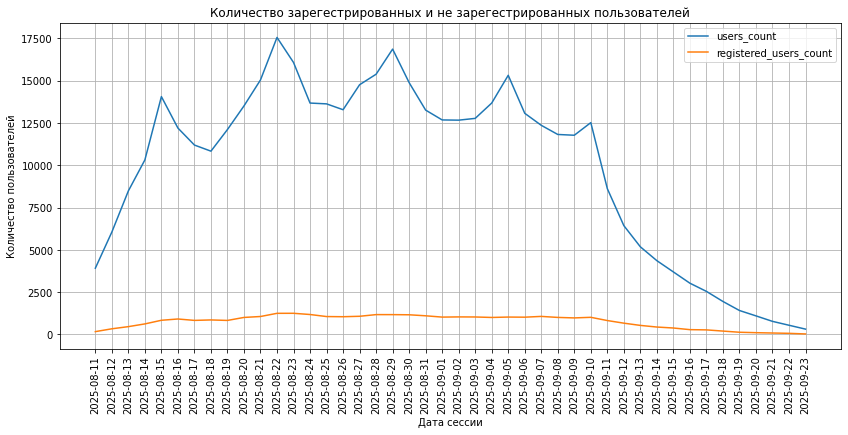

In [10]:
# Строим график общего числа пользователей и зарегистрированных пользователей по дням
plt.figure(figsize=(14, 6))

plt.plot(daily_users.session_date, daily_users.users_count, label='users_count')
plt.plot(daily_users.session_date, daily_users.registered_users_count, label='registered_users_count')


plt.xlabel('Дата сессии')
plt.ylabel('Количество пользователей')
plt.title('Количество зарегистрированных и не зарегистрированных пользователей')
plt.legend()
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

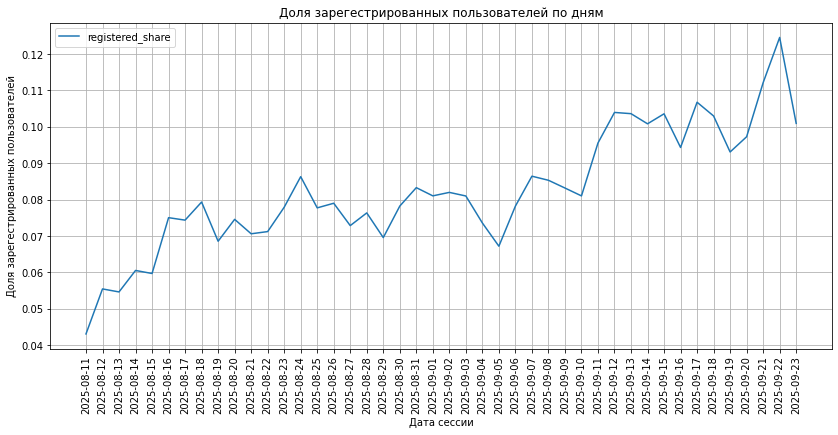

In [11]:
# Построим график доли зарегистрированных пользователей по дням
plt.figure(figsize=(14, 6))

plt.plot(daily_users.session_date, daily_users.registered_share, label='registered_share')

plt.xlabel('Дата сессии')
plt.ylabel('Доля зарегистрированных пользователей')
plt.title('Доля зарегистрированных пользователей по дням')
plt.legend()
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Пик пользовательской активности наблюдается 22 августа 2025 года, после чего число активных пользователей снижается. Число зарегистрированных пользователей заметно ниже общего числа активных пользователей, поэтому отдельно рассматриваю и динамику их доли.


### 1.4. Просмотры страниц в первой сессии

Анализирую распределение числа просмотренных страниц в первой сессии пользователя.


In [12]:
# Выведем количество просмотров страниц в рамках первых сессий пользователей
sessions_count = sessions_history.page_counter[sessions_history['session_number'] == 1].value_counts(sort=False)
sessions_count

1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: page_counter, dtype: int64

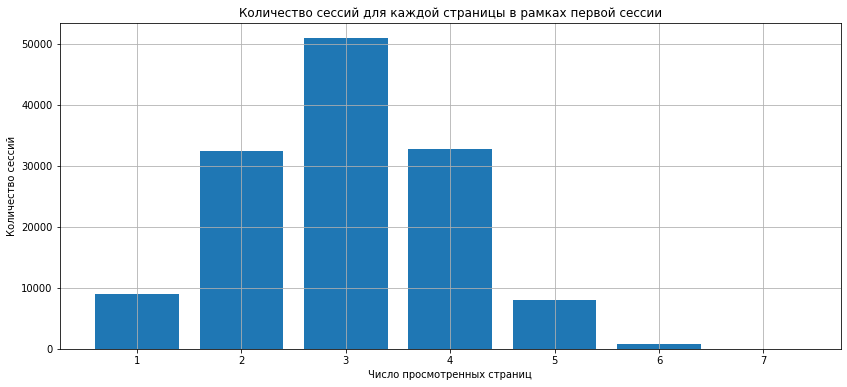

In [13]:
plt.figure(figsize=(14, 6))

plt.bar(sessions_count.index, sessions_count.values)

plt.title('Количество сессий для каждой страницы в рамках первой сессии')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid()
plt.show()

Чаще всего в первой сессии пользователи просматривают от 2 до 4 страниц. После 4 страниц количество первых сессий резко уменьшается: большинство новых пользователей ограничивается коротким знакомством с приложением.


### 1.5. Прокси-метрика вовлечённости

Определяю **успешную первую сессию** как первую сессию, в которой пользователь просмотрел не менее 4 страниц. Далее рассчитываю долю таких сессий по дням.


In [14]:
# Создадим новый столбец в датафрейме sessions_history и заполним его значением 0
sessions_history['good_session'] = 0

In [15]:
# Заполним столбец good_session значениями 1, если это первая сессия и пользователь посмотрел 4 и более страниц
sessions_history.loc[sessions_history['page_counter'] >= 4, 'good_session'] = 1

In [16]:
# Создадим переменную с первыми сессиями пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [17]:
# Агрегируем значения первых сессий 
daily_good_session_share = first_sessions.groupby('session_date', as_index=False).agg(
                                                          good_session_share=('good_session', 'mean'))

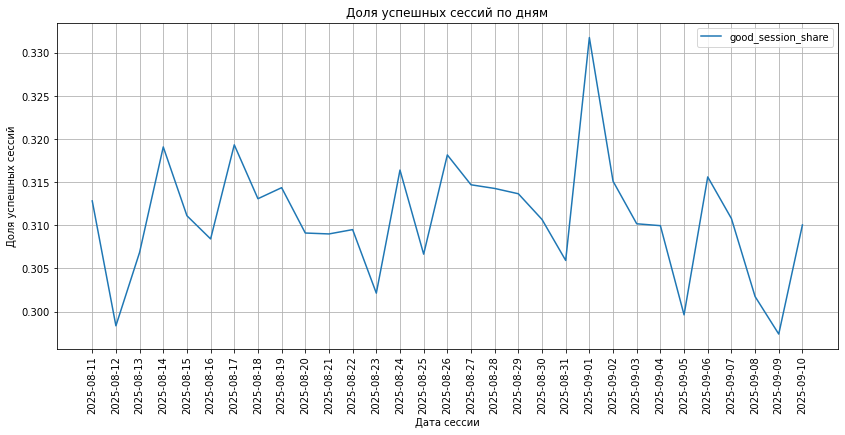

In [18]:
# Построим график с долей успешных первых сессий пользователей по дням
plt.figure(figsize=(14, 6))

plt.plot(daily_good_session_share.session_date, daily_good_session_share.good_session_share, label='good_session_share')

plt.title('Доля успешных сессий по дням')
plt.xlabel('Дата сессии')
plt.ylabel('Доля успешных сессий')
plt.grid()
plt.legend()
plt.xticks(rotation=90)
plt.show()

Доля успешных первых сессий в основном находится в диапазоне 30–32%. Отдельные дни отличаются локальными просадками или ростом, но выраженного устойчивого тренда за период не наблюдается.


## 2. Планирование A/B-теста

Для запуска эксперимента определяю необходимый размер выборки и минимальную длительность теста на основе исторического трафика.


### 2.1. Расчёт размера выборки

Параметры расчёта:
- уровень значимости α = 0.05;
- мощность = 0.8;
- базовая доля успешных первых сессий ≈ 0.30;
- MDE = 3% относительно базового уровня.

Размер выборки рассчитываю с помощью `NormalIndPower`.


In [20]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import math

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p * (1 + mde))

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


### 2.2. Минимальная длительность теста

Оцениваю среднее число уникальных пользователей в день и рассчитываю, сколько дней потребуется для набора плановой выборки в двух группах.


In [21]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f'Среднее количество пользователей в день: {avg_daily_users:.0f}')
print(f'Длительность A/B-теста: {test_duration} дней')

Среднее количество пользователей в день: 9907
Длительность A/B-теста: 9 дней


## 3. Проверка корректности A/B-теста


### 3.1. Баланс размеров групп

На данных первых дней эксперимента проверяю число уникальных пользователей в группах A и B и оцениваю процентную разницу между ними.


In [22]:
# Создадим датафрейм sessions_test_part из csv файла
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [23]:
# Посчитаем количество уникальных пользователей для каждой тестовой группы
unique_users = sessions_test_part.groupby('test_group')['user_id'].nunique()
unique_users

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [24]:
# Посчитаем процентную разницу
p_diff = 100 * abs(unique_users['A'] - unique_users['B']) / unique_users['A']
p_diff

0.7447528774542993

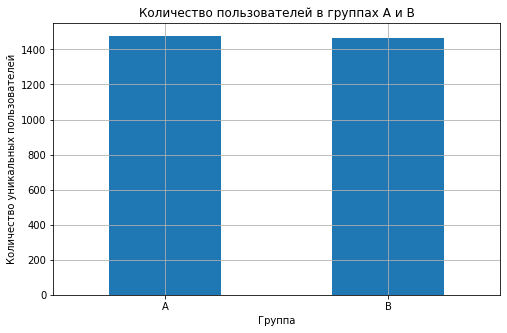

In [25]:
# Построим столбчатую диаграмму с количество пользователей в группах
unique_users.plot(kind='bar', figsize=(8, 5), grid=True)

plt.title('Количество пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=0)
plt.show()

Группы близки по размеру: разница между A и B составляет менее 1%, поэтому существенного перекоса по числу пользователей не наблюдается.


### 3.2. Проверка пересечения пользователей

Проверяю независимость выборок: один и тот же пользователь не должен одновременно находиться в группах A и B.


In [26]:
# Выведем количество пользователей, входящих в обе группы
a_group = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
b_group = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(a_group) & set(b_group))
len(intersection)

0

Пересечений пользователей между группами A и B не обнаружено.


### 3.3. Баланс по устройствам

Сравниваю распределение пользователей по типам устройств в группах A и B.


In [27]:
# Оставим уникальных пользователей
users_devices = sessions_test_part[['user_id', 'test_group', 'device']].drop_duplicates()

In [28]:
# Посчитаем доли каждого типа устройств для групп А и B
device_share_a = (
    users_devices[users_devices['test_group'] == 'A']['device']
    .value_counts(normalize=True)
)

device_share_b = (
    users_devices[users_devices['test_group'] == 'B']['device']
    .value_counts(normalize=True)
)

In [29]:
# Выведем доли устройств обеих групп
device_share_a, device_share_b

(Android    0.444144
 PC         0.249831
 iPhone     0.200406
 Mac        0.105619
 Name: device, dtype: float64,
 Android    0.455662
 PC         0.259891
 iPhone     0.183492
 Mac        0.100955
 Name: device, dtype: float64)

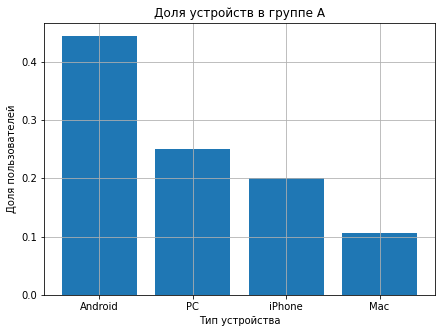

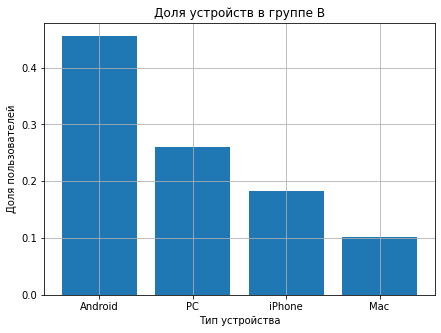

In [30]:
# Построим 2 графика долей типов устройств для групп А и B
# Группа A
plt.figure(figsize=(7, 5))
plt.bar(device_share_a.index, device_share_a.values)

plt.title('Доля устройств в группе A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(True)
plt.show()


# Группа B
plt.figure(figsize=(7, 5))
plt.bar(device_share_b.index, device_share_b.values)

plt.title('Доля устройств в группе B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid(True)
plt.show()

Распределения по устройствам в группах A и B близки; заметного перекоса не наблюдается.


### 3.4. Баланс по регионам

Сравниваю распределение пользователей по регионам в группах A и B.


In [31]:
# Оставим уникальных пользователей
users_region = sessions_test_part[['user_id', 'test_group', 'region']].drop_duplicates()

In [32]:
# Посчитаем доли каждого региона для групп А и B
region_share_a = (
    users_region[users_region['test_group'] == 'A']['region']
    .value_counts(normalize=True)
)

region_share_b = (
    users_region[users_region['test_group'] == 'B']['region']
    .value_counts(normalize=True)
)

In [33]:
# Выведем доли регионов обеих групп
region_share_a, region_share_b

(CIS     0.436019
 MENA    0.412322
 EU      0.151659
 Name: region, dtype: float64,
 CIS     0.439973
 MENA    0.412005
 EU      0.148022
 Name: region, dtype: float64)

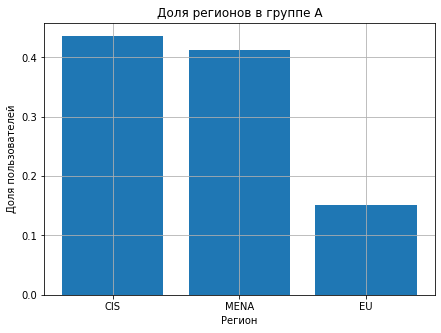

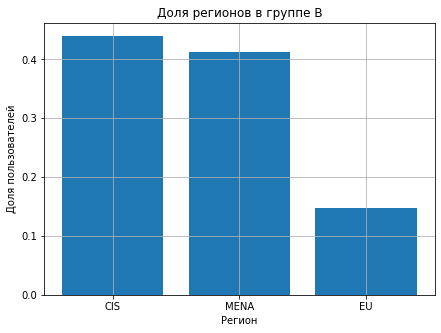

In [34]:
# Построим 2 графика долей регионов для групп А и B
# Группа A
plt.figure(figsize=(7, 5))
plt.bar(region_share_a.index, region_share_a.values)

plt.title('Доля регионов в группе A')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.grid(True)
plt.show()


# Группа B
plt.figure(figsize=(7, 5))
plt.bar(region_share_b.index, region_share_b.values)

plt.title('Доля регионов в группе B')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.grid(True)
plt.show()

### 3.5. Вывод по проверке сплита


Разделение пользователей на группы прошло корректно. В группе A — 1477 пользователей, в группе B — 1466; разница составляет около 0.74%. Пересечений пользователей между группами не обнаружено. Распределения по устройствам и регионам также близки.

Критических нарушений, которые могли бы исказить результат A/B-теста, на этапе мониторинга не выявлено.


## 4. Анализ результатов A/B-теста


### 4.1. Подготовка итоговых данных

Загружаю итоговые данные эксперимента и формирую признак `good_session`: значение 1 соответствует сессии с 4 и более просмотренными страницами.


In [35]:
# Загрузим датасет 
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [36]:
# Создадим новый столбец в датафрейме sessions_test и заполним его нулями
sessions_test['good_session'] = 0

In [37]:
# Заменим нули на 1 там, где в рамках одной сессии пользователь просмотрел 4 или больше страниц
sessions_test.loc[sessions_test['page_counter'] >= 4, 'good_session'] = 1

### 4.2. Гипотезы и дополнительные метрики

Проверяется предположение, что новый алгоритм увеличивает долю успешных первых сессий.

В качестве дополнительной прокси-метрики можно отслеживать среднее число просмотренных страниц. В качестве барьерных метрик — технические показатели, например время загрузки страницы и частоту ошибок.


**Нулевая гипотеза H₀:** доля успешных первых сессий в группе B не выше, чем в группе A.

**Альтернативная гипотеза H₁:** доля успешных первых сессий в группе B выше, чем в группе A.

В обозначениях долей:

**H₀: p_B ≤ p_A**

**H₁: p_B > p_A**


### 4.3. Наблюдаемое изменение ключевой метрики

Рассчитываю долю успешных первых сессий в каждой тестовой группе.


In [38]:
# Отберем только первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

In [40]:
first_sessions.groupby('test_group')['good_session'].mean()

test_group
A    0.315724
B    0.314673
Name: good_session, dtype: float64

Наблюдаемая доля успешных первых сессий:
- группа A — **31.57%**;
- группа B — **31.47%**.

Разница B − A составляет примерно **−0.11 п.п.**: в тестовой группе метрика не выросла. Далее проверяю, является ли различие статистически значимым.


### 4.4. Статистическая проверка

Для односторонней проверки сравниваю значения бинарной метрики `good_session` в группах A и B при уровне значимости α = 0.05.


In [41]:
from scipy.stats import ttest_ind

sample_a = first_sessions[first_sessions['test_group']=='A']['good_session']
sample_b = first_sessions[first_sessions['test_group']=='B']['good_session']

test_result = ttest_ind(
    sample_a,
    sample_b,
    alternative='less' 
)
alpha = 0.05

if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue={test_result.pvalue} < {alpha}')
    print('Отвергаем нулевую гипотезу') 

pvalue=0.578349228097416 > 0.05
Не получилось отвергнуть нулевую гипотезу


Получено **p-value = 0.578**, что выше уровня значимости 0.05. Оснований отвергать H₀ нет: статистически значимого роста доли успешных первых сессий в группе B не обнаружено.

Это не доказывает отсутствие эффекта вообще, но эксперимент не дал подтверждения ожидаемого улучшения ключевой метрики.


### 4.5. Итоговый вывод


Для планирования эксперимента требовалось около **41 040 пользователей на группу**, а минимальная расчётная длительность составляла **9 дней**. Итоговый датасет охватывает период с 14 октября по 2 ноября 2025 года, то есть **20 дней наблюдения**.

По итогам теста доля успешных первых сессий составила **31.57% в группе A** и **31.47% в группе B**. Изменение составило около **−0.11 п.п.** в пользу контрольной группы.

Односторонний статистический тест дал **p-value = 0.578 > 0.05**. Статистически значимого улучшения ключевой метрики после внедрения нового алгоритма не обнаружено.

**Вывод:** текущая версия рекомендательного алгоритма не показала ожидаемого положительного эффекта, поэтому данных для её внедрения по результатам этого эксперимента недостаточно.
